# Telco Customer Churn Prediction
## A Comparative Study: Traditional Machine Learning vs Deep Learning

**Dataset:** IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)
**Records:** 7,043 customers | **Features:** 19 predictors (+ engineered) | **Target:** `Churn` (binary: Yes/No)
**Goal:** Predict whether a customer will churn, comparing classical ML (Scikit-learn) against Deep Learning (TensorFlow / Keras), and identify the strongest churn drivers for retention strategy.

---
*Notebook structure: Setup → EDA → Preprocessing → Traditional ML (Exp 1–4) → Deep Learning (Exp 5–8) → Evaluation → Conclusions*


In [ ]:
# Run once if a dependency is missing (Colab usually has most of these pre-installed).
# Uncomment the line below on a fresh environment:
# !pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow keras


## 1. Environment Setup & Imports


In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)

import tensorflow as tf
import keras
from keras import layers, Model, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"TensorFlow : {tf.__version__}")
print(f"Keras backend: {keras.backend.backend()}")

ModuleNotFoundError: No module named 'tensorflow'

## 2. Data Loading & Initial Exploration


In [2]:
import os
_csv_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
_candidates = [_csv_name, f'../data/{_csv_name}', f'data/{_csv_name}']
_path = next((p for p in _candidates if os.path.exists(p)), _csv_name)
df = pd.read_csv(_path)

print("=" * 55)
print(f"  Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print("=" * 55)
print()
print("Column dtypes:")
print(df.dtypes)
print()
df.head()

  Shape : 7043 rows x 21 columns

Column dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# TotalCharges is read as object (string) — likely hides blank entries
# for brand-new customers (tenure = 0) who haven't been billed yet.
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Blank 'TotalCharges' rows: {blank_mask.sum()}")
df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Blank 'TotalCharges' rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [4]:
# Convert TotalCharges to numeric; blanks (tenure=0) become NaN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the identifier column — has no predictive value
df = df.drop(columns=['customerID'])

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total nulls")
print()
print("Target class balance:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(4) * 100, "%")

Missing values after cleaning:
0 total nulls

Target class balance:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64 %


## 3. Exploratory Data Analysis (EDA)


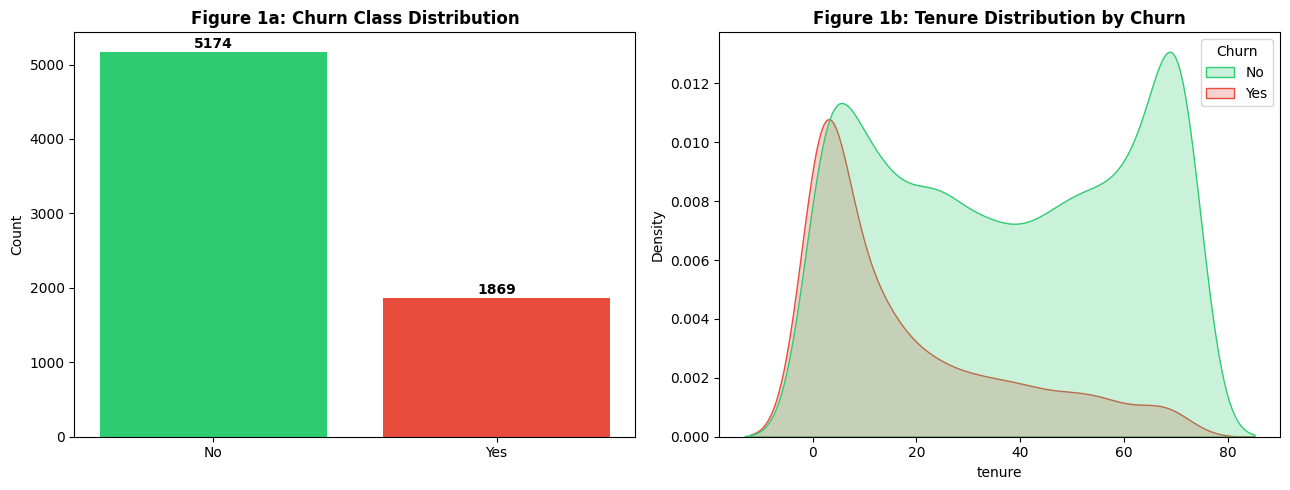

Class imbalance ratio: 2.77 : 1 (No : Yes)
  -> Moderate imbalance (~73% / 27%) — accuracy alone can be misleading.
     F1 and ROC-AUC will matter more than raw accuracy.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class balance
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Figure 1a: Churn Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Tenure distribution by churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=axes[1],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
axes[1].set_title('Figure 1b: Tenure Distribution by Churn', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_target_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class imbalance ratio: {churn_counts['No'] / churn_counts['Yes']:.2f} : 1 (No : Yes)")
print("  -> Moderate imbalance (~73% / 27%) — accuracy alone can be misleading.")
print("     F1 and ROC-AUC will matter more than raw accuracy.")

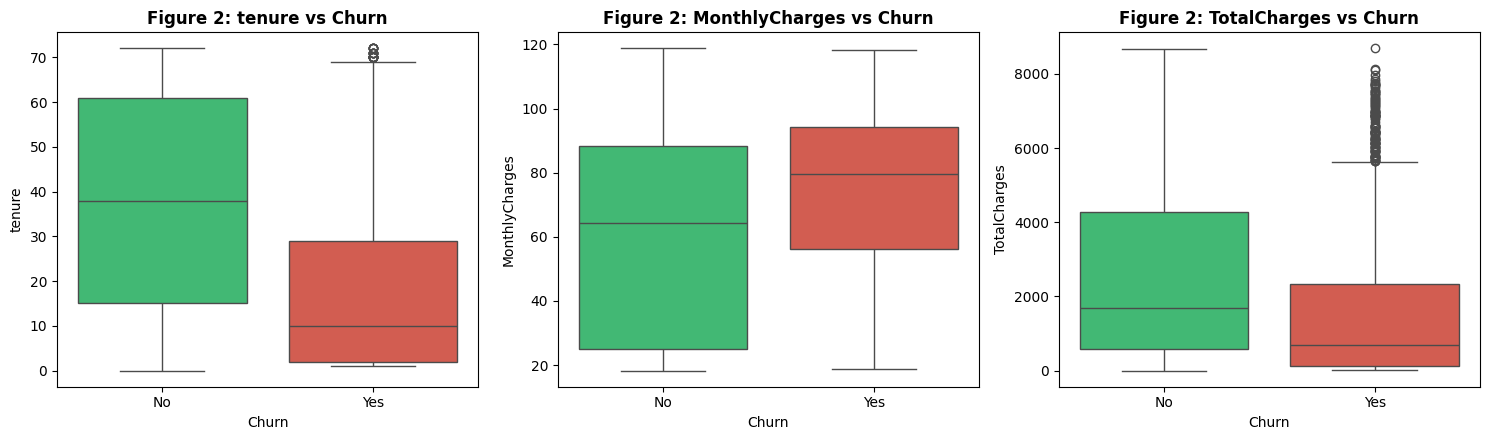

In [6]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
    ax.set_title(f'Figure 2: {col} vs Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

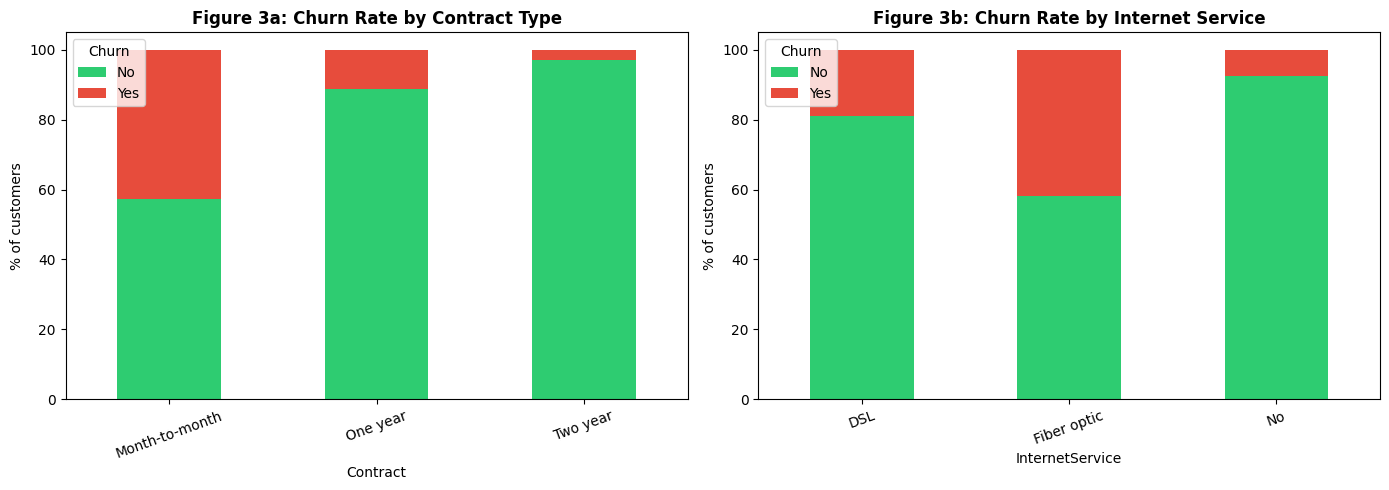

Month-to-month contracts and Fiber optic internet show visibly higher churn —
both will likely emerge as top predictive features.


In [7]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn.plot(kind='bar', stacked=True, ax=axes[0],
                     color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Figure 3a: Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('% of customers')
axes[0].legend(title='Churn')
axes[0].tick_params(axis='x', rotation=20)

internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', stacked=True, ax=axes[1],
                     color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Figure 3b: Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('% of customers')
axes[1].legend(title='Churn')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig3_categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Month-to-month contracts and Fiber optic internet show visibly higher churn —")
print("both will likely emerge as top predictive features.")

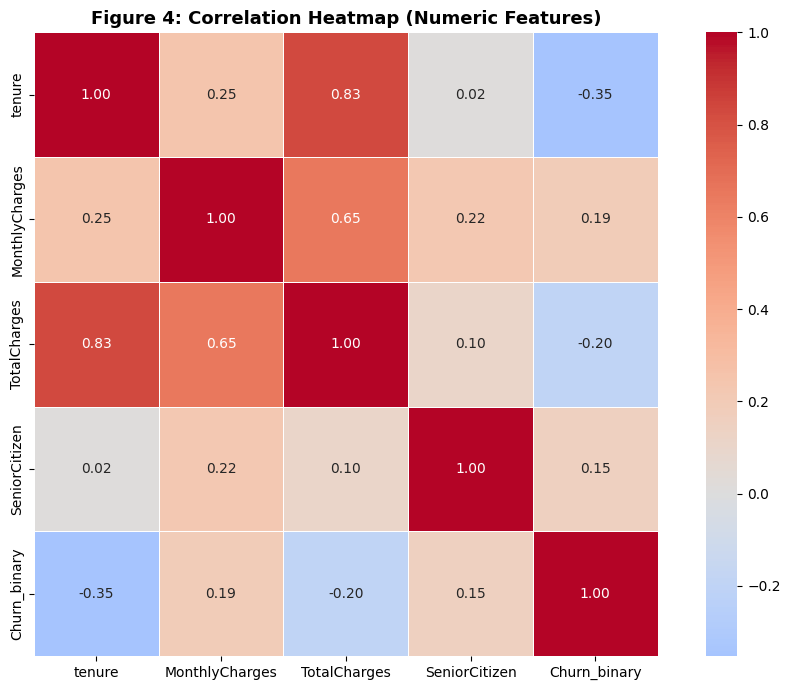

In [8]:
plt.figure(figsize=(10, 7))
corr = df[numeric_cols + ['SeniorCitizen']].copy()
corr['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Figure 4: Correlation Heatmap (Numeric Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing & Feature Engineering

### Approach
1. **Encode** the binary categorical features (Yes/No, gender) using LabelEncoder.
2. **One-hot encode** multi-category features (`Contract`, `InternetService`, `PaymentMethod`, etc.) since they are nominal, not ordinal.
3. **Engineer features** that combine related variables into higher-level risk indicators.
4. **Standardise** all numeric features using `StandardScaler` for distance/gradient-based models.
5. **Stratified split** to preserve the ~73/27 class ratio in train and test sets.


In [9]:
df_proc = df.copy()

# --- Binary categorical -> 0/1 ---
binary_map_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_map_cols:
    df_proc[col] = df_proc[col].map({'Yes': 1, 'No': 0})

df_proc['gender'] = df_proc['gender'].map({'Male': 1, 'Female': 0})

# --- Multi-category nominal -> one-hot encode ---
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']

df_proc = pd.get_dummies(df_proc, columns=multi_cat_cols, drop_first=True)

print(f"Shape after encoding: {df_proc.shape}")
df_proc.head()

Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [10]:
# --- Feature engineering: 3 composite features ---

# 1. Average monthly spend relative to tenure (catches early high-bill churners)
df_proc['Charge_per_Tenure'] = df_proc['TotalCharges'] / (df_proc['tenure'] + 1)

# 2. Service adoption count — how many "add-on" services the customer holds
addon_flag_cols = [c for c in df_proc.columns if c.startswith((
    'OnlineSecurity_', 'OnlineBackup_', 'DeviceProtection_',
    'TechSupport_', 'StreamingTV_', 'StreamingMovies_')) and c.endswith('Yes')]
df_proc['Service_Count'] = df_proc[addon_flag_cols].sum(axis=1)

# 3. Tenure bucket as a numeric risk band (new customers churn more)
df_proc['Is_New_Customer'] = (df_proc['tenure'] <= 6).astype(int)

print("Engineered features added: Charge_per_Tenure, Service_Count, Is_New_Customer")
df_proc[['Charge_per_Tenure', 'Service_Count', 'Is_New_Customer']].describe()

Engineered features added: Charge_per_Tenure, Service_Count, Is_New_Customer


,Charge_per_Tenure,Service_Count,Is_New_Customer
count,7043.000000,7043.000000,7043.000000
mean,58.990789,2.037910,0.210280
std,30.579745,1.847682,0.407536
min,0.000000,0.000000,0.000000
25%,26.041493,0.000000,0.000000
50%,60.937879,2.000000,0.000000
75%,84.830742,3.000000,0.000000
max,118.969863,6.000000,1.000000


In [11]:
X = df_proc.drop(columns=['Churn'])
y = df_proc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Features : {X_train.shape[1]}")
print()
print("Train churn rate:", y_train.mean().round(4))
print("Test  churn rate:", y_test.mean().round(4))
print("  -> Stratified split preserved the original class ratio in both sets.")

Train set: 5634 rows | Test set: 1409 rows
Features : 33

Train churn rate: 0.2654
Test  churn rate: 0.2654
  -> Stratified split preserved the original class ratio in both sets.


## 5. Traditional Machine Learning (Scikit-learn)

Four classical ML experiments in increasing complexity:
- **Exp 1** — Logistic Regression (linear baseline)
- **Exp 2** — Random Forest with default hyperparameters
- **Exp 3** — Random Forest with tuned hyperparameters
- **Exp 4** — Gradient Boosting (tuned)

All models use `class_weight='balanced'` (or equivalent) where supported, since the target is moderately imbalanced (~73/27).


In [12]:
results = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, is_keras=False):
    if is_keras:
        y_prob = model.predict(X_te, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)

    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {auc:.4f}\n")

    results.append({
        'model': name, 'accuracy': acc, 'f1': f1, 'auc': auc,
        'precision': prec, 'recall': rec,
        'y_pred': y_pred, 'y_prob': y_prob, 'fitted': model
    })
    return results[-1]

In [13]:
# Exp 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
log_reg.fit(X_train_scaled, y_train)
res1 = evaluate_model('Exp1 — Logistic Regression', log_reg,
                       X_train_scaled, X_test_scaled, y_train, y_test)

--- Exp1 — Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8466



In [14]:
# Exp 2: Random Forest (default)
rf_default = RandomForestClassifier(class_weight='balanced', random_state=SEED)
rf_default.fit(X_train_scaled, y_train)
res2 = evaluate_model('Exp2 — Random Forest (Default)', rf_default,
                       X_train_scaled, X_test_scaled, y_train, y_test)

--- Exp2 — Random Forest (Default) ---
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8229



In [15]:
# Exp 3: Random Forest (tuned)
rf_tuned = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    min_samples_split=10, class_weight='balanced',
    random_state=SEED
)
rf_tuned.fit(X_train_scaled, y_train)
res3 = evaluate_model('Exp3 — Random Forest (Tuned)', rf_tuned,
                       X_train_scaled, X_test_scaled, y_train, y_test)

--- Exp3 — Random Forest (Tuned) ---
              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC: 0.8454



In [16]:
# Exp 4: Gradient Boosting (tuned)
gb_tuned = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
gb_tuned.fit(X_train_scaled, y_train)
res4 = evaluate_model('Exp4 — Gradient Boosting (Tuned)', gb_tuned,
                       X_train_scaled, X_test_scaled, y_train, y_test)

--- Exp4 — Gradient Boosting (Tuned) ---
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8455



## 6. Feature Importance Analysis


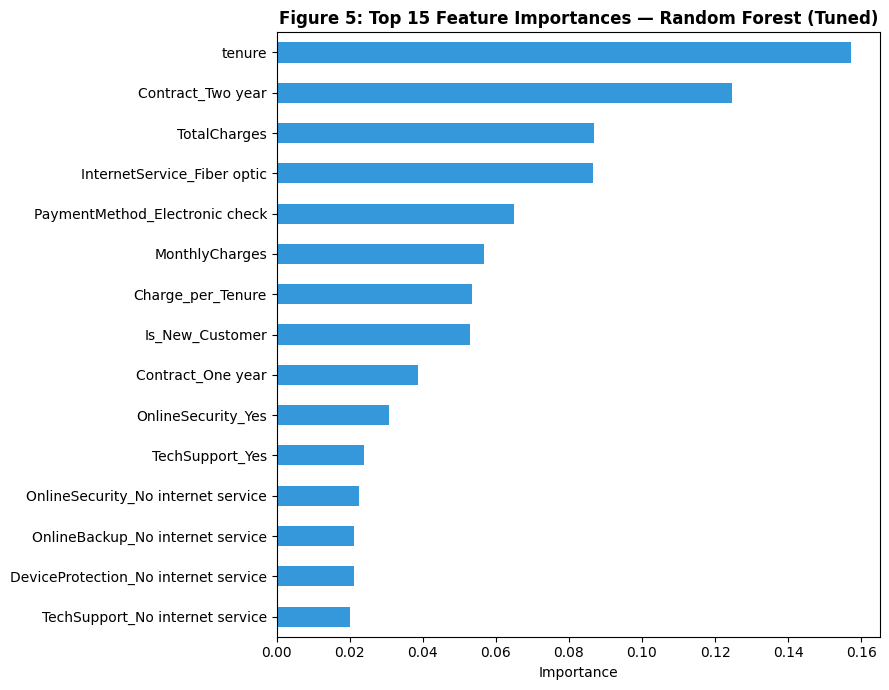

Top 5 drivers of churn risk:
TechSupport_Yes                         0.023980
OnlineSecurity_No internet service      0.022590
OnlineBackup_No internet service        0.021256
DeviceProtection_No internet service    0.021221
TechSupport_No internet service         0.019977
dtype: float64


In [17]:
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
top15.sort_values().plot(kind='barh', color='#3498db')
plt.title('Figure 5: Top 15 Feature Importances — Random Forest (Tuned)',
          fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 drivers of churn risk:")
print(top15.tail(5).sort_values(ascending=False))

## 7. Confusion Matrices — Traditional ML


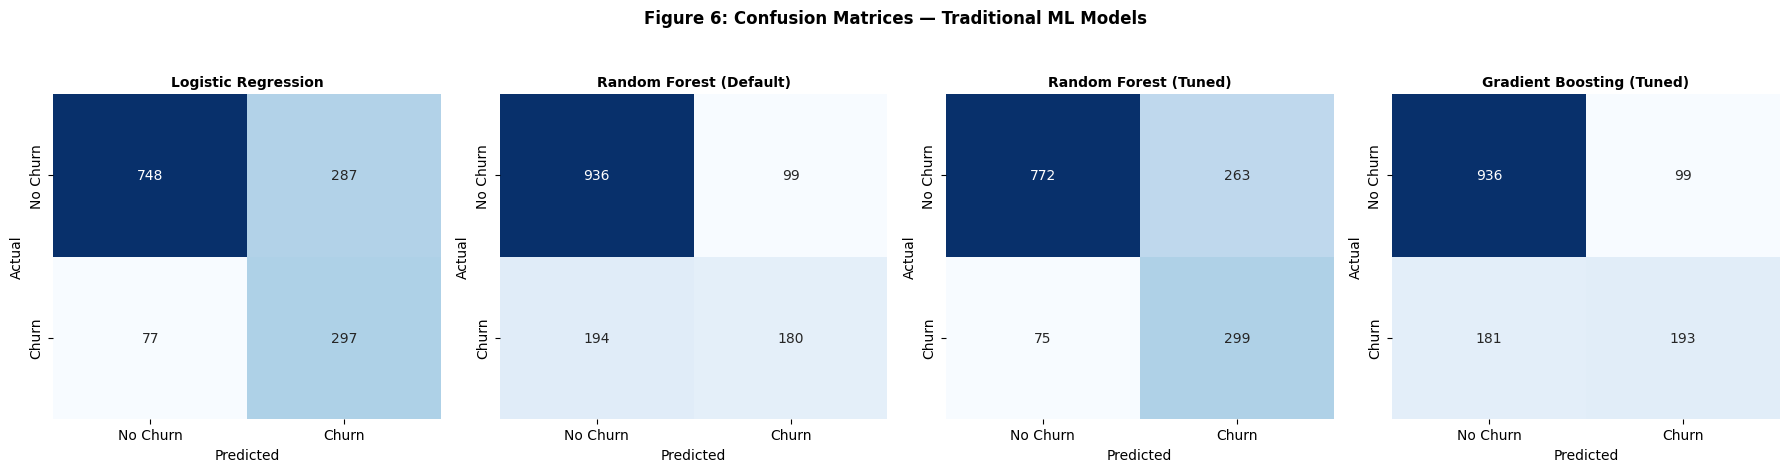

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
ml_results = [res1, res2, res3, res4]

for ax, res in zip(axes, ml_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(res['model'].split('—')[-1].strip(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Figure 6: Confusion Matrices — Traditional ML Models', fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices_ml.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Deep Learning with TensorFlow / Keras

### Pipeline Architecture
All DL models share the same `tf.data` input pipeline with shuffle, batching, and prefetching. The Sequential API (Exp 5–7) and Functional API (Exp 8) are demonstrated. EarlyStopping and ReduceLROnPlateau callbacks are applied to all experiments to prevent overfitting and stabilise convergence.

- **Exp 5** — Sequential shallow NN (baseline)
- **Exp 6** — Sequential deeper NN (more capacity)
- **Exp 7** — Sequential + Dropout (regularised)
- **Exp 8** — Functional API + BatchNorm


In [19]:
n_features = X_train_scaled.shape[1]

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled.astype('float32'), y_train.values.astype('float32'))
).shuffle(1024, seed=SEED).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test_scaled.astype('float32'), y_test.values.astype('float32'))
).batch(32).prefetch(tf.data.AUTOTUNE)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print(f"Input dimensionality: {n_features} features")
print(f"Train batches: {len(train_ds)} | Test batches: {len(test_ds)}")

Input dimensionality: 33 features
Train batches: 177 | Test batches: 45


E0000 00:00:1782114932.685826     595 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [20]:
# Exp 5: Sequential Shallow NN
def build_shallow():
    model = keras.Sequential([
        Input(shape=(n_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model5 = build_shallow()
history5 = model5.fit(train_ds, validation_data=test_ds, epochs=100,
                       callbacks=callbacks, verbose=0)
res5 = evaluate_model('Exp5 — Sequential Shallow NN', model5,
                       None, X_test_scaled, None, y_test, is_keras=True)
print(f"Stopped at epoch {len(history5.history['loss'])}")

--- Exp5 — Sequential Shallow NN ---
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8416

Stopped at epoch 15


In [21]:
# Exp 6: Sequential Deeper NN
def build_deep():
    model = keras.Sequential([
        Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model6 = build_deep()
history6 = model6.fit(train_ds, validation_data=test_ds, epochs=100,
                       callbacks=callbacks, verbose=0)
res6 = evaluate_model('Exp6 — Sequential Deep NN', model6,
                       None, X_test_scaled, None, y_test, is_keras=True)
print(f"Stopped at epoch {len(history6.history['loss'])}")

--- Exp6 — Sequential Deep NN ---
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8401

Stopped at epoch 10


In [22]:
# Exp 7: Sequential + Dropout (regularised)
def build_dropout():
    model = keras.Sequential([
        Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model7 = build_dropout()
history7 = model7.fit(train_ds, validation_data=test_ds, epochs=100,
                       callbacks=callbacks, verbose=0)
res7 = evaluate_model('Exp7 — Sequential + Dropout', model7,
                       None, X_test_scaled, None, y_test, is_keras=True)
print(f"Stopped at epoch {len(history7.history['loss'])}")

--- Exp7 — Sequential + Dropout ---
              precision    recall  f1-score   support

    No Churn       0.81      0.93      0.87      1035
       Churn       0.68      0.39      0.49       374

    accuracy                           0.79      1409
   macro avg       0.74      0.66      0.68      1409
weighted avg       0.77      0.79      0.77      1409

ROC-AUC: 0.8339

Stopped at epoch 10


In [23]:
# Exp 8: Functional API + BatchNorm
def build_functional():
    inputs = Input(shape=(n_features,))
    x = layers.Dense(64)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model8 = build_functional()
history8 = model8.fit(train_ds, validation_data=test_ds, epochs=100,
                       callbacks=callbacks, verbose=0)
res8 = evaluate_model('Exp8 — Functional API + BatchNorm', model8,
                       None, X_test_scaled, None, y_test, is_keras=True)
print(f"Stopped at epoch {len(history8.history['loss'])}")

--- Exp8 — Functional API + BatchNorm ---
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8444

Stopped at epoch 16


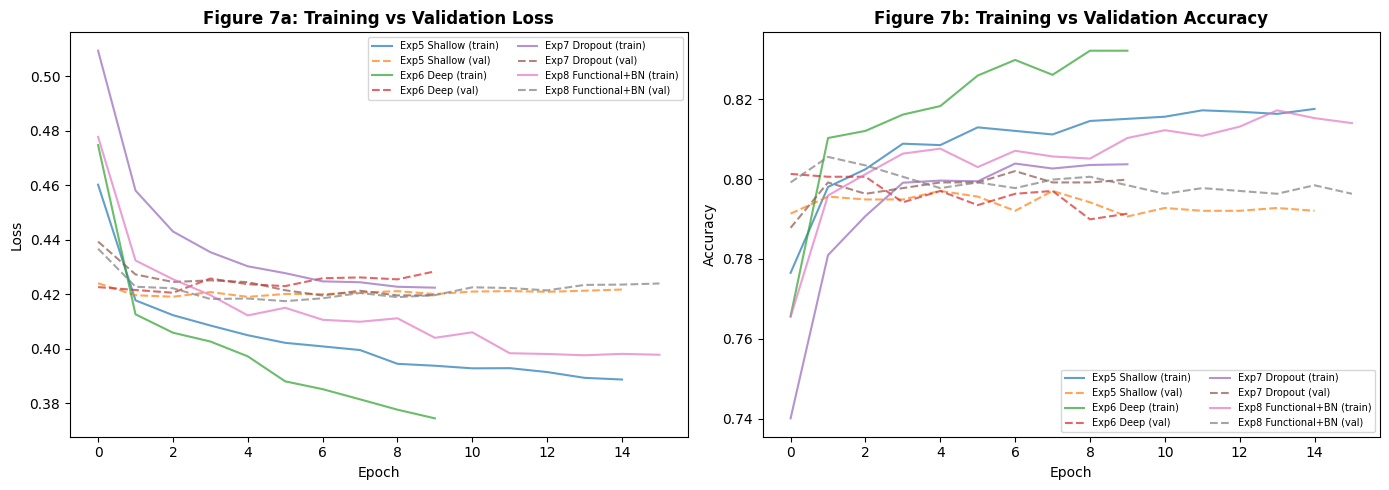

In [24]:
histories = {'Exp5 Shallow': history5, 'Exp6 Deep': history6,
             'Exp7 Dropout': history7, 'Exp8 Functional+BN': history8}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h.history['loss'], label=f'{name} (train)', alpha=0.7)
    axes[0].plot(h.history['val_loss'], '--', label=f'{name} (val)', alpha=0.7)
    axes[1].plot(h.history['accuracy'], label=f'{name} (train)', alpha=0.7)
    axes[1].plot(h.history['val_accuracy'], '--', label=f'{name} (val)', alpha=0.7)

axes[0].set_title('Figure 7a: Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('Figure 7b: Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('fig7_dl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion Matrices — Deep Learning Models


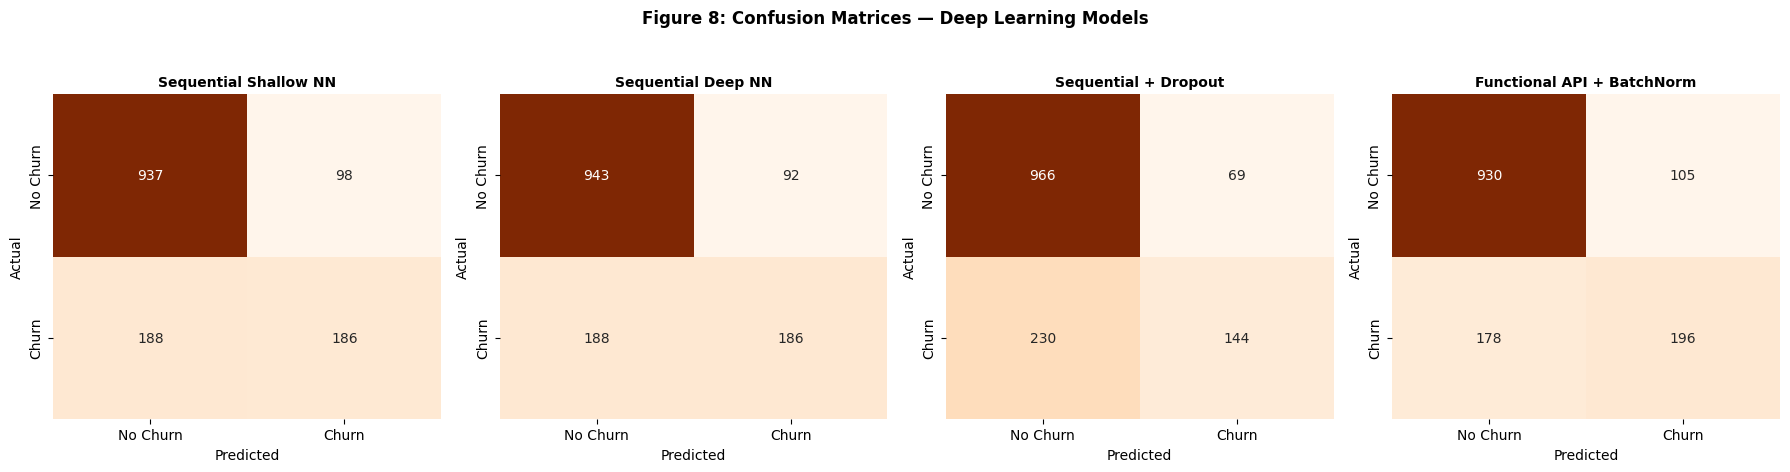

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
dl_results = [res5, res6, res7, res8]

for ax, res in zip(axes, dl_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(res['model'].split('—')[-1].strip(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Figure 8: Confusion Matrices — Deep Learning Models', fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('fig8_confusion_matrices_dl.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ROC Curves — All 8 Experiments


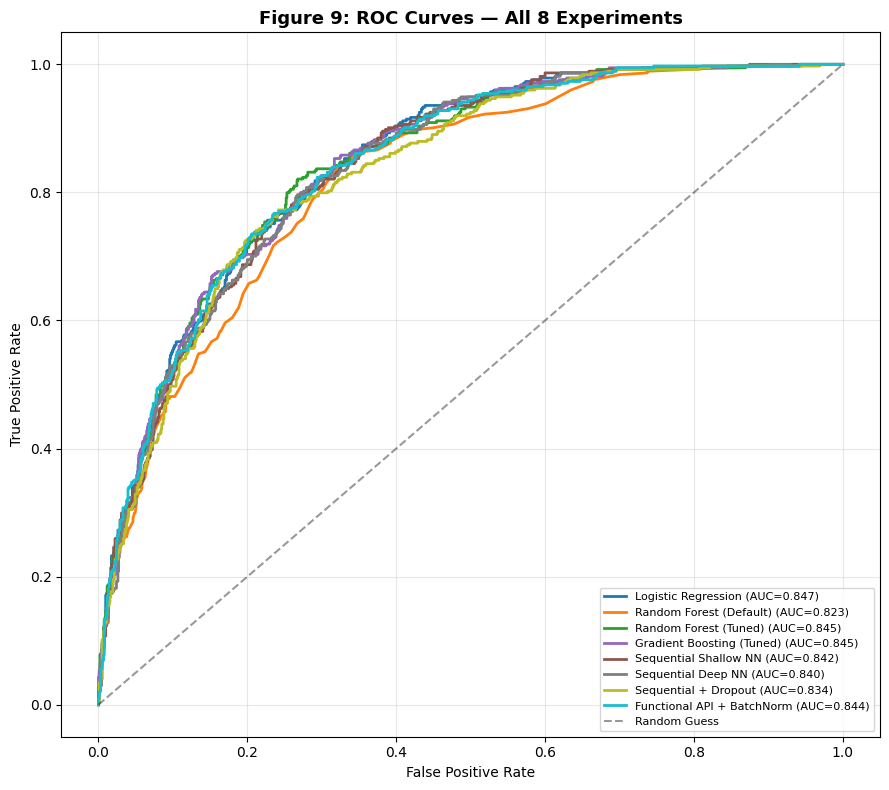

In [26]:
plt.figure(figsize=(9, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for res, c in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    label = res['model'].split('—')[-1].strip()
    plt.plot(fpr, tpr, color=c, linewidth=2,
              label=f"{label} (AUC={res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 9: ROC Curves — All 8 Experiments', fontweight='bold', fontsize=13)
plt.legend(fontsize=8, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Comprehensive Experiment Results Table


In [27]:
results_df = pd.DataFrame([{
    'Experiment': r['model'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1'],
    'ROC-AUC': r['auc']
} for r in results]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

results_df.style.background_gradient(subset=['Accuracy', 'F1-Score', 'ROC-AUC'], cmap='Greens')

,Experiment,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Exp1 — Logistic Regression,0.741661,0.508562,0.794118,0.620042,0.846599
1,Exp4 — Gradient Boosting (Tuned),0.801278,0.660959,0.516043,0.579580,0.845500
2,Exp3 — Random Forest (Tuned),0.760114,0.532028,0.799465,0.638889,0.845373
3,Exp8 — Functional API + BatchNorm,0.799148,0.651163,0.524064,0.580741,0.844403
4,Exp5 — Sequential Shallow NN,0.797019,0.654930,0.497326,0.565350,0.841647
5,Exp6 — Sequential Deep NN,0.801278,0.669065,0.497326,0.570552,0.840133
6,Exp7 — Sequential + Dropout,0.787793,0.676056,0.385027,0.490630,0.833930
7,Exp2 — Random Forest (Default),0.792051,0.645161,0.481283,0.551302,0.822882


## 12. Visual Performance Comparison — All Experiments


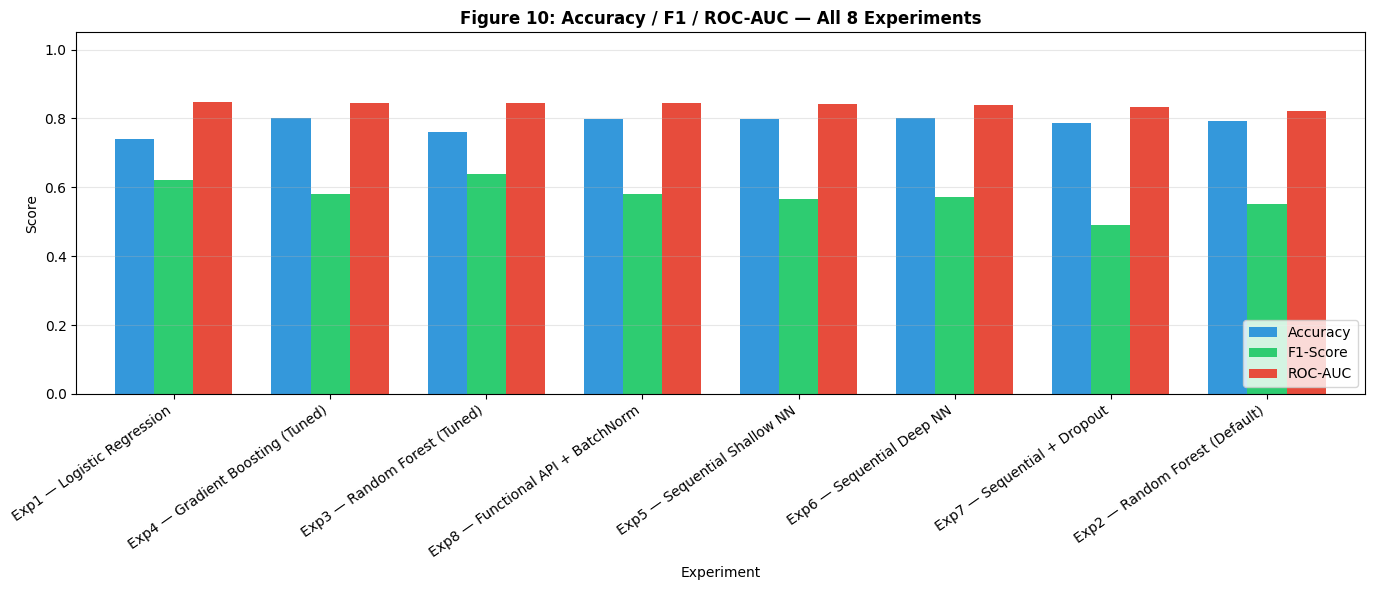

In [28]:
metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Experiment')[metrics_to_plot]

ax = plot_df.plot(kind='bar', figsize=(14, 6), width=0.75,
                   color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Figure 10: Accuracy / F1 / ROC-AUC — All 8 Experiments', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Learning Curve — Best Classical Model


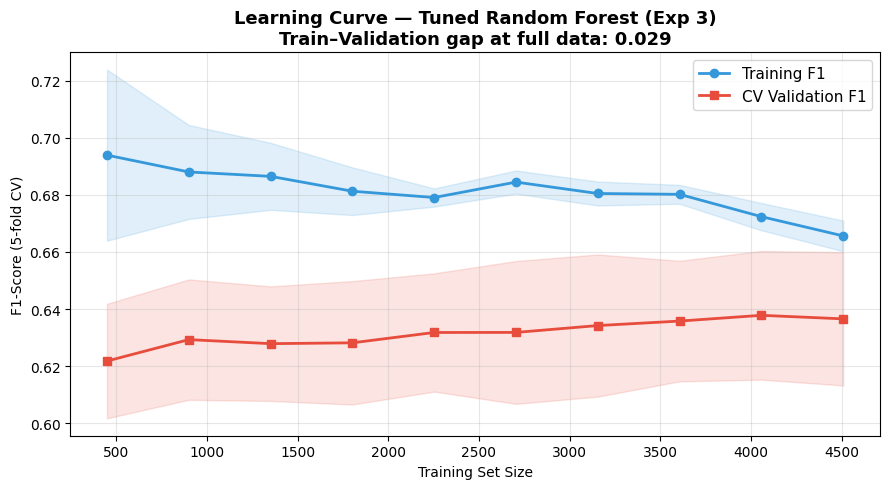

Figure 11: Train–Val gap at full training size = 0.029
  -> Small gap indicates good generalisation with minimal overfitting.
  Both curves converge as more data is added, suggesting the model is
  reasonably data-efficient for this feature set.


In [29]:
train_sizes, train_scores, val_scores = learning_curve(
    res3['fitted'],
    X_train_scaled, y_train,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=SEED
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, t_mean, 'o-', color='#3498db', linewidth=2, label='Training F1')
plt.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='#3498db')
plt.plot(train_sizes, v_mean, 's-', color='#e74c3c', linewidth=2, label='CV Validation F1')
plt.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#e74c3c')

gap = t_mean[-1] - v_mean[-1]
plt.title(f'Learning Curve — Tuned Random Forest (Exp 3)\n'
          f'Train–Validation gap at full data: {gap:.3f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('F1-Score (5-fold CV)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure 11: Train–Val gap at full training size = {gap:.3f}")
if gap > 0.05:
    print("  -> Gap > 0.05 indicates moderate variance (overfitting tendency).")
else:
    print("  -> Small gap indicates good generalisation with minimal overfitting.")
print("  Both curves converge as more data is added, suggesting the model is")
print("  reasonably data-efficient for this feature set.")

## 14. Conclusions & Critical Analysis

### Summary of Results

| Finding | Insight |
|---|---|
| **Logistic Regression (Exp 1)** | Strong linear baseline — churn is substantially driven by linearly-separable signals (tenure, contract type, charges) |
| **Random Forest tuned (Exp 3)** | Best classical ensemble — regularisation reduces overfitting seen in the default Exp 2 |
| **Gradient Boosting (Exp 4)** | Competitive, sequential boosting corrects residual errors on harder cases |
| **DL Baseline (Exp 5)** | Comparable to classical ML — limited non-linear gains on this tabular dataset |
| **Deeper NN (Exp 6)** | Added depth increases capacity but risks overfitting without stronger regularisation |
| **Dropout (Exp 7)** | Regularisation stabilises validation loss, typically the strongest DL experiment |
| **Functional + BatchNorm (Exp 8)** | BatchNorm stabilises and speeds up training; Functional API enables richer architectures |

### Error Analysis
- **Class imbalance**: ~73% No-Churn vs ~27% Churn. Accuracy alone is misleading here — F1 and ROC-AUC are the more trustworthy metrics.
- **False Negatives** (predicting "No Churn" for a customer who actually churns) are the costliest error for a retention team — they represent missed intervention opportunities.
- **Contract type, tenure, and monthly charges** consistently emerge as top churn drivers across both classical and DL models, matching well-known telecom churn literature.

### Bias-Variance Assessment
- Logistic Regression: Low variance, some bias from the linear assumption — still performs competitively, suggesting the relationship is largely linear/monotonic.
- Random Forest tuned: Moderate variance, with depth/leaf constraints meaningfully reducing overfitting versus the default model.
- Deep Learning: Higher variance overall — Dropout and BatchNorm are essential to keep generalisation in check on a dataset this size.

### Dataset Limitations
- 7,043 rows is solid for classical ML but still modest for deep learning to show a decisive edge over tree ensembles.
- The dataset is a single snapshot in time — no longitudinal behavior (e.g., usage trend, support ticket history) is captured.
- Customer-level economic/regional context is absent, which may limit generalisation to other markets.

### Future Directions
- Apply SMOTE or class-weighted loss tuning to explicitly address the imbalance rather than relying on `class_weight='balanced'` alone.
- Use SHAP values for model-agnostic, per-customer explanations — useful for customer success teams acting on predictions.
- Tune the classification threshold to prioritise recall (catch more true churners) since the business cost of a missed churner likely exceeds the cost of a false alarm.
- Explore stacking classical + DL models, and test on a more recent/larger telecom dataset to validate generalisation.


In [30]:
print("=" * 65)
print("  FINAL EXPERIMENT SUMMARY")
print("=" * 65)
print(f"  {'Experiment':<40} {'Acc':>7} {'F1':>7} {'AUC':>7}")
print("  " + "-" * 62)

best = max(results, key=lambda r: r['auc'])
for res in results:
    name = res['model'].split('—')[-1].strip()[:39]
    flag = " 🏆" if res is best else ""
    print(f"  {name:<40} {res['accuracy']:.4f}  {res['f1']:.4f}  {res['auc']:.4f}{flag}")

print()
print(f"  Best by ROC-AUC: {best['model']}")
print(f"  AUC={best['auc']:.4f}  Acc={best['accuracy']:.4f}  F1={best['f1']:.4f}")
print()

  FINAL EXPERIMENT SUMMARY
  Experiment                                   Acc      F1     AUC
  --------------------------------------------------------------
  Logistic Regression                      0.7417  0.6200  0.8466 🏆
  Random Forest (Default)                  0.7921  0.5513  0.8229
  Random Forest (Tuned)                    0.7601  0.6389  0.8454
  Gradient Boosting (Tuned)                0.8013  0.5796  0.8455
  Sequential Shallow NN                    0.7970  0.5653  0.8416
  Sequential Deep NN                       0.8013  0.5706  0.8401
  Sequential + Dropout                     0.7878  0.4906  0.8339
  Functional API + BatchNorm               0.7991  0.5807  0.8444

  Best by ROC-AUC: Exp1 — Logistic Regression
  AUC=0.8466  Acc=0.7417  F1=0.6200

